This notebook registrates Xray ESRF data of slice A to absorption data from diffraction meassurements at DANMAX.
For running this notebook, you will need access to the folder "/dtu-compute/msaca/...". You will need the scripts module_auxiliary.py and stitcher_XA.py. You will need the libraries: h5py, matplotlib.pyplot, numpy, tifffile, os Additionally, the libraries sys, importlib, scipy, astropy, and re are imported, but not used.

In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import os
os.chdir('/zhome/71/c/146676/main/')
from helpers import module_auxiliary as ma
from loaders import stitcher_XA
from loaders import loader_XA_to_NA
import SimpleITK as sitk

Import diffraction data

In [5]:
with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/highres_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset = f["absorption"]
    DA_1 = dataset[:,320:580]


with h5py.File("/dtu-compute/msaca/sliceA_diffraction/abs_volume/overview_abs_volume.h5", "r") as f:
    # List all groups and datasets
    print("Keys:", list(f.keys()))
    
    # Access a dataset (replace 'dataset_name' with an actual name from the keys)
    dataset = f["absorption"]
    DA_2 = dataset[:,120:240]

Keys: ['absorption']
Keys: ['absorption']


Import Xray ESRF data of slice A, that matches the same region as the diffraction data (found using trial and error)

In [6]:
paths_XA = stitcher_XA.generate_batch_stitched_paths(dataset = 'tv', folders = [3,4],
            start_indices = [350, 94], end_indices = [694, 450])
ny, nx = np.shape(tifffile.imread(paths_XA[0]))
XA = np.empty((len(paths_XA),ny,nx))
for i in range(len(paths_XA)):
    XA[i] = tifffile.imread(paths_XA[-i])

In [20]:

xray_slices = range(1250,1950)
neutron_slices = range(600,1000)
output_volume = [[600,1000],[None], [None]]
reg = loader_XA_to_NA.load_subset_of_registered_data(dataset_XA='tv', dataset_NA='tv' , h=1, xray_slices = xray_slices,
    neutron_slices = neutron_slices, output_volume = output_volume)

Resampling the transformation
Resampling moving image


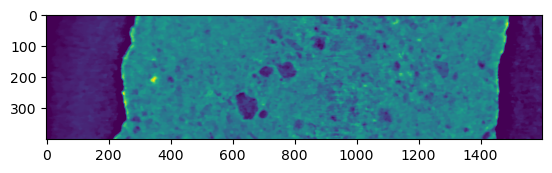

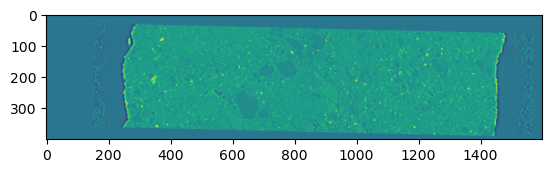

In [21]:
plt.imshow(sitk.GetArrayFromImage(reg.fixed)[:,100,:])
plt.show()
plt.imshow(sitk.GetArrayFromImage(reg.moving)[:,100,:])
plt.show()

In [22]:
XA = sitk.GetArrayFromImage(reg.moving)
NA = sitk.GetArrayFromImage(reg.fixed)
print(np.shape(DA_1))
print(np.shape(DA_2))
print(np.shape(XA))
print(np.shape(NA))

(14, 260, 902)
(71, 120, 362)
(400, 360, 1600)
(400, 360, 1600)


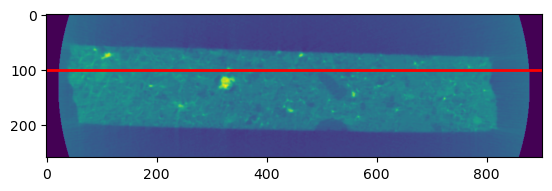

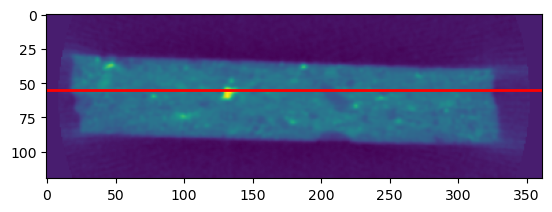

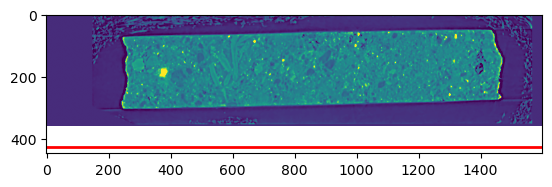

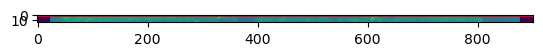

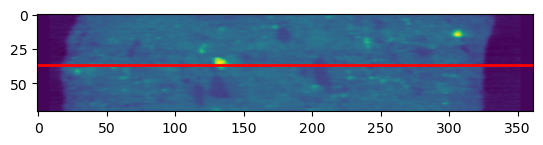

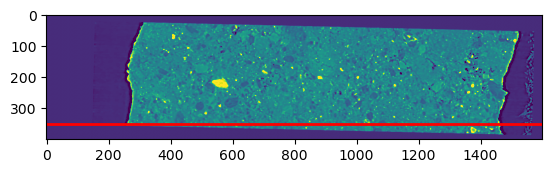

In [24]:
plt.imshow(DA_1[0])
plt.axhline(y=100, color='r', linewidth=2)
plt.show()
plt.imshow(DA_2[37])
plt.axhline(y=55, color='r', linewidth=2)
plt.show()
plt.imshow(XA[350])
plt.axhline(y=425, color='r', linewidth=2)
plt.clim([-0.01,0.07])
plt.show()
plt.imshow(DA_1[:,100])
plt.axhline(y=0, color='r', linewidth=2)
plt.show()
plt.imshow(DA_2[:,55])
plt.axhline(y=37, color='r', linewidth=2)
plt.show()
plt.imshow(XA[:,225])
plt.axhline(y=350, color='r', linewidth=2)
plt.clim([-0.01,0.07])
plt.show()

Find the threshold values

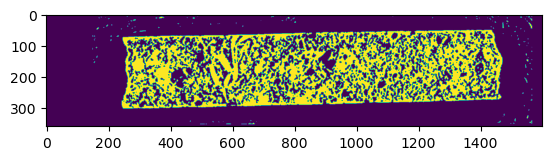

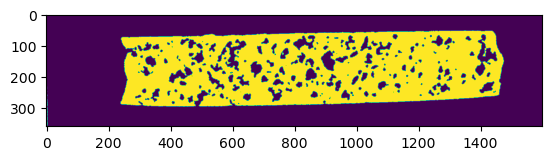

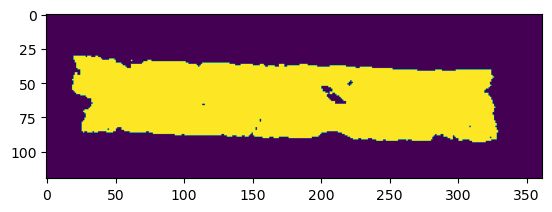

In [26]:
plt.imshow(XA[350]>0.025)
plt.show()
plt.imshow(NA[350]>0.025)
plt.show()
plt.imshow(DA_2[37]>0.0045)
plt.show()


Cast the two volumes to simple ITK images, and set the spacing

In [44]:
_ , nx_XA = np.shape(XA[0])
_ , nx_DA_2 = np.shape(DA_2[0])

fixed = sitk.GetImageFromArray(DA_2)
moving = sitk.GetImageFromArray(XA)
moving_NA = sitk.GetImageFromArray(NA)
fixed.SetSpacing((1/nx_DA_2,1/nx_DA_2,1/nx_DA_2))
moving.SetSpacing((1/nx_XA,1/nx_XA,1/nx_XA))
moving_NA.SetSpacing((1/nx_XA,1/nx_XA,1/nx_XA))

size_fixed = fixed.GetSize()
size_moving = moving.GetSize()
size_moving = moving_NA.GetSize()

spacing_fixed = fixed.GetSpacing()
spacing_moving = moving.GetSpacing()

# Compute the new origin (shift it to -N/2)
new_origin_fixed = [-0.5 * (size_fixed[i] - 1) * spacing_fixed[i] for i in range(len(size_fixed))]
new_origin_moving = [-0.5 * (size_moving[i] - 1) * spacing_moving[i] for i in range(len(size_moving))]
new_origin_moving_NA = [-0.5 * (size_moving[i] - 1) * spacing_moving[i] for i in range(len(size_moving))]


fixed.SetOrigin(new_origin_fixed)
moving.SetOrigin(new_origin_moving)
moving_NA.SetOrigin(new_origin_moving_NA)

Downsize the x-ray data for increased speed in the registration

In [53]:
factor = 2

transform = sitk.Transform(3, sitk.sitkIdentity)
# Get the original size and spacing of the image
size = moving.GetSize()
spacing = moving.GetSpacing()

# Calculate the new size (downsampling by factor)
new_size = [int(size[0] / factor), int(size[1] / factor), int(size[2] / factor)]

# Calculate the new spacing (enlarging the spacing to match the downsampled size)
new_spacing = [s * factor for s in spacing]

# Perform the resampling (using average interpolation for downsampling)
moving_d = sitk.Resample(moving,
                                new_size,
                                transform,
                                sitk.sitkLinear,  # BSpline interpolation is good for downsampling
                                moving.GetOrigin(),
                                new_spacing,
                                moving.GetDirection(),
                                0)  # 0 is the background value for the resampling

moving_NA_d = sitk.Resample(moving_NA,
                                new_size,
                                transform,
                                sitk.sitkLinear,  # BSpline interpolation is good for downsampling
                                moving_NA.GetOrigin(),
                                new_spacing,
                                moving_NA.GetDirection(),
                                0)  # 0 is the background value for the resampling


Define registrator loop and resampler. A threshold method is used with gradient descent on the thresholded images.

In [54]:
def registrator(fixed, moving, thresholds = [0.0045, 0.025], sampling_percentage = 0.1, max_iter = 1000, learning_rate = 1):

    fixed_d = sitk.BinaryThreshold(fixed, lowerThreshold=thresholds[0], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    moving_d = sitk.BinaryThreshold(moving, lowerThreshold=thresholds[1], upperThreshold=float("inf"), insideValue=1, outsideValue=0)
    fixed_d =sitk.Cast(fixed_d, sitk.sitkFloat32)
    moving_d =sitk.Cast(moving_d, sitk.sitkFloat32)

    initial_transform = sitk.Similarity3DTransform()
    initial_transform.SetMatrix([1.0, 0.0, 0.0,
                                0.0, 1.0, 0.0,
                                0.0, 0.0, 1.0])

    # Set the translation to zero
    initial_transform.SetTranslation([0.0, 0.0, 0.0])
    initial_transform.SetScale(1.0)

    registration = sitk.ImageRegistrationMethod()
    registration.SetInitialTransform(initial_transform)
    registration.SetMetricAsMeanSquares()
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(sampling_percentage)

    registration.SetOptimizerAsGradientDescent(
        learningRate=learning_rate,
        numberOfIterations=max_iter,
        convergenceMinimumValue=-1e-16,
        convergenceWindowSize=1000
        )

    registration.SetInterpolator(sitk.sitkLinear)
    registration.Execute(fixed_d, moving_d)
    transform = registration.GetInitialTransform()
    return transform

def resampler(fixed, moving, transform):
    resampler = sitk.ResampleImageFilter()
    resampler.SetReferenceImage(fixed)  # Reference image (fixed)
    resampler.SetInterpolator(sitk.sitkLinear)   # Interpolation method
    resampler.SetTransform(transform)    # Apply the initial transform (aligned centroids)
    resampler.SetOutputPixelType(fixed.GetPixelID())
    resampler.SetOutputSpacing(fixed.GetSpacing())  # Ensure the spacing is preserved
    resampler.SetOutputOrigin(fixed.GetOrigin())  # Preserve origin
    resampler.SetOutputDirection(fixed.GetDirection())
    moving = resampler.Execute(moving)
    return moving

Alternative method with mattes mutual information on the non-thresholded images.

In [55]:
def registrator2(fixed, moving, sampling_percentage = 0.1, max_iter = 1000, learning_rate = 1,histogram_bins = 50):

    fixed_d = fixed
    moving_d = moving
    fixed_d =sitk.Cast(fixed_d, sitk.sitkFloat32)
    moving_d =sitk.Cast(moving_d, sitk.sitkFloat32)

    initial_transform = sitk.Similarity3DTransform()
    initial_transform.SetMatrix([1.0, 0.0, 0.0,
                                0.0, 1.0, 0.0,
                                0.0, 0.0, 1.0])

    # Set the translation to zero
    initial_transform.SetTranslation([0.0, 0.0, 0.0])
    initial_transform.SetScale(1.0)

    registration = sitk.ImageRegistrationMethod()
    registration.SetInitialTransform(initial_transform)
    registration.SetMetricAsMattesMutualInformation(numberOfHistogramBins=histogram_bins)
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(sampling_percentage)

    registration.SetOptimizerAsGradientDescent(
        learningRate=learning_rate,
        numberOfIterations=max_iter,
        convergenceMinimumValue=-1e-16,
        convergenceWindowSize=1000
        )

    registration.SetInterpolator(sitk.sitkLinear)
    registration.Execute(fixed_d, moving_d)
    transform = registration.GetInitialTransform()
    return transform


Call the registration using the first method

In [60]:
transform = registrator(fixed, moving_d, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 1000, learning_rate = 0.3)
moving_temp = resampler(fixed, moving_d, transform)
moving_NA_temp = resampler(fixed, moving_NA_d, transform)


#transform = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 100, learning_rate = 0.2)
#moving_temp = resampler(fixed, moving_temp, transform)
#moving_NA_temp = resampler(fixed, moving_NA_temp, transform)

#transform = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 100, learning_rate = 0.2)
#moving_temp = resampler(fixed, moving_temp, transform)
#moving_NA_temp = resampler(fixed, moving_NA_temp, transform)

#transform = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 100, learning_rate = 0.1)
#moving_temp = resampler(fixed, moving_temp, transform)
#moving_NA_temp = resampler(fixed, moving_NA_temp, transform)

#transform = registrator(fixed, moving_temp, thresholds = [0.0045, 0.025], sampling_percentage = 1, max_iter = 100, learning_rate = 0.05)
#moving_temp = resampler(fixed, moving_temp, transform)
#moving_NA_temp = resampler(fixed, moving_NA_temp, transform)

Also run the second method

In [57]:
#transform = registrator2(fixed, moving_d, sampling_percentage = 0.2, max_iter = 200, learning_rate = 1, histogram_bins = 20)
#moving_temp2 = resampler(fixed, moving, transform)

#transform = registrator2(fixed, moving_temp2, sampling_percentage = 1, max_iter = 200, learning_rate = 0.5, histogram_bins = 20)
#moving_temp2 = resampler(fixed, moving_temp2, transform)


#transform = registrator2(fixed, moving_temp2, sampling_percentage = 1, max_iter = 200, learning_rate = 0.2, histogram_bins = 20)
#moving_temp2 = resampler(fixed, moving_temp2, transform)


#transform = registrator2(fixed, moving_temp2, sampling_percentage = 1, max_iter = 200, learning_rate = 0.1, histogram_bins = 20)
#moving_temp2 = resampler(fixed, moving_temp2, transform)

#transform = registrator2(fixed, moving_temp2, sampling_percentage = 1, max_iter = 200, learning_rate = 0.05, histogram_bins = 10)
#moving_temp2 = resampler(fixed, moving_temp2, transform)

Make plotter ufnction

In [61]:
def plotter(XA_temp = XA_temp, DA_2 = DA_2):
    plt.imshow(XA_temp[10])
    plt.clim([0.01,0.07])
    plt.show()

    plt.imshow(XA_temp[:,50])
    plt.clim([0.01,0.07])
    plt.show()

    plt.imshow(DA_2[10])
    plt.show()

    plt.imshow(DA_2[:,50])
    plt.show()

    thresholds = [0.0045, 0.025]
    plt.imshow(XA_temp[10]>thresholds[1])
    plt.clim([0.01,0.07])
    plt.show()

    plt.imshow(DA_2[10] > thresholds[0])
    plt.show()

    plt.imshow((DA_2[10] > thresholds[0])*1.0 - (XA_temp[10] > thresholds[1])*1.0)
    plt.show()

    plt.imshow(XA_temp[:,50]>thresholds[1])
    plt.clim([0.012,0.075])
    plt.show()

    plt.imshow(DA_2[:,50] > thresholds[0])
    plt.show()

    plt.imshow((DA_2[:,50] > thresholds[0])*1.0 - (XA_temp[:,50] > thresholds[1])*1.0)
    plt.show()


Show the plot (only using the first method here)

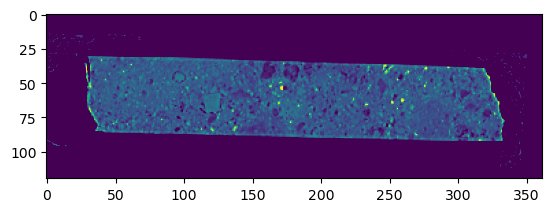

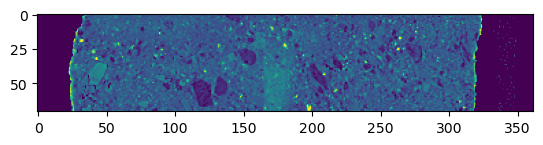

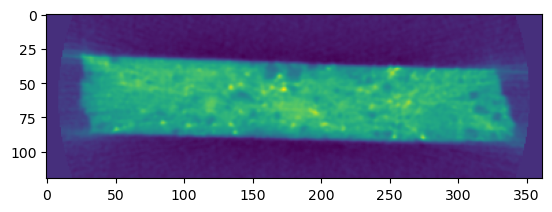

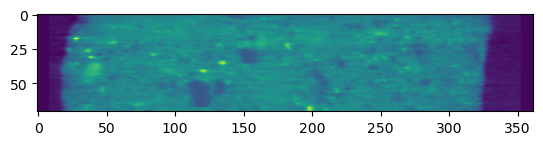

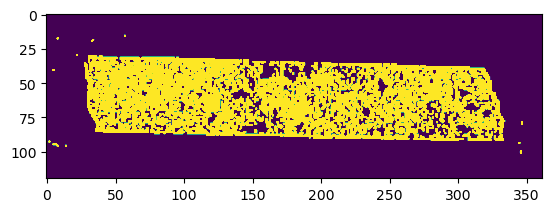

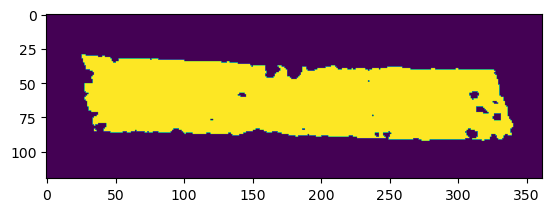

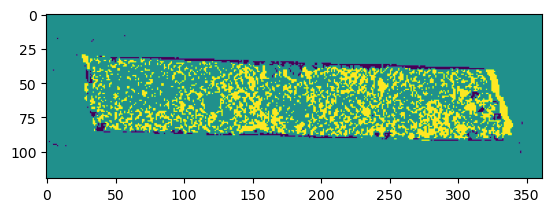

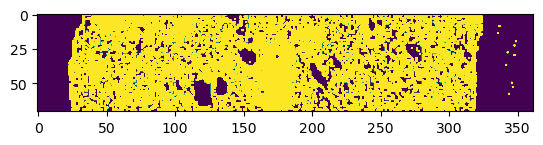

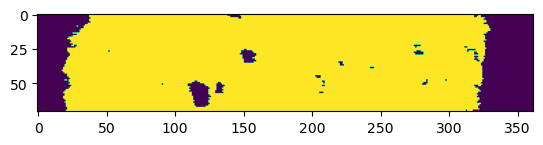

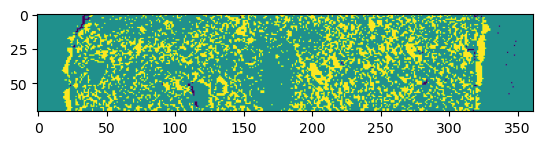

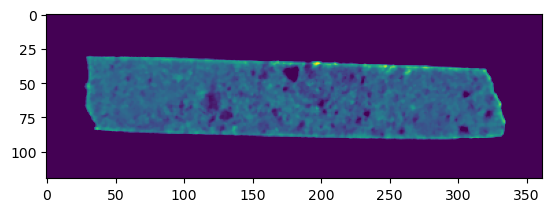

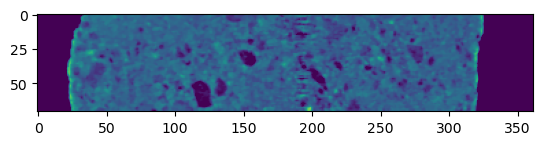

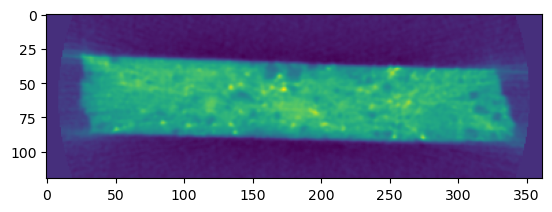

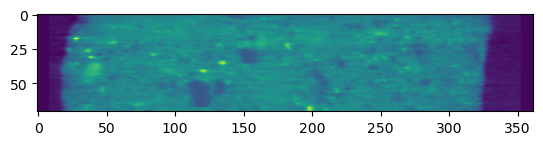

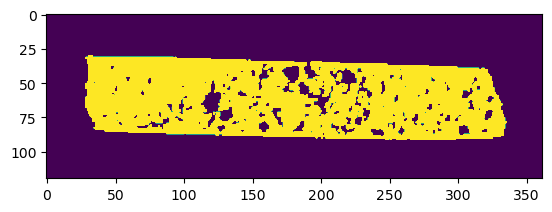

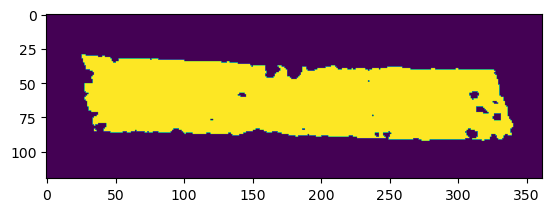

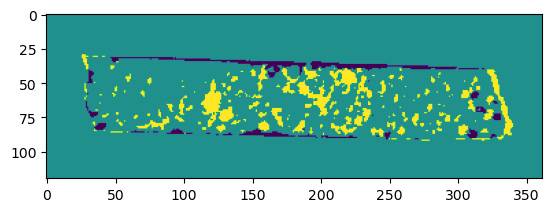

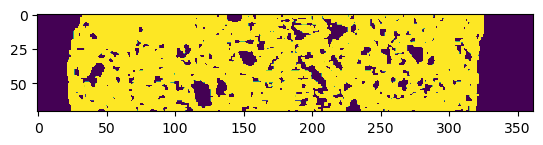

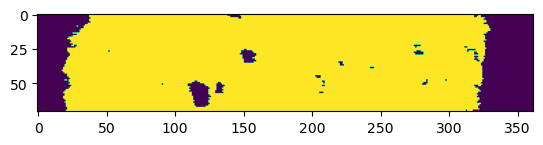

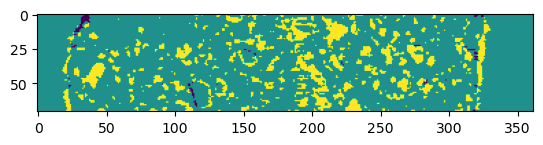

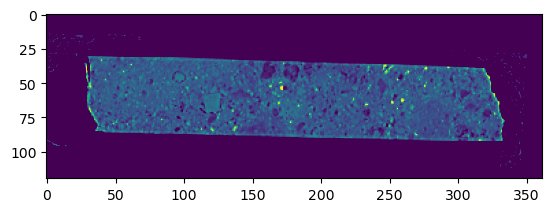

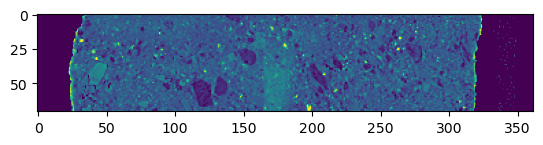

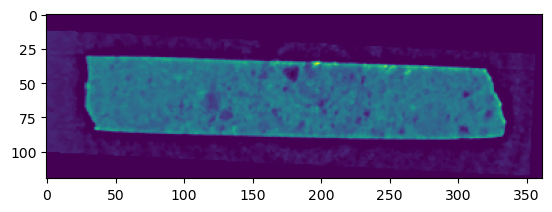

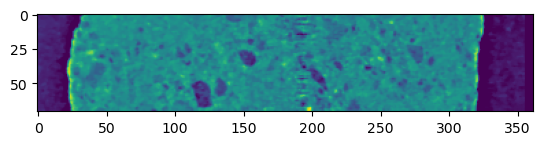

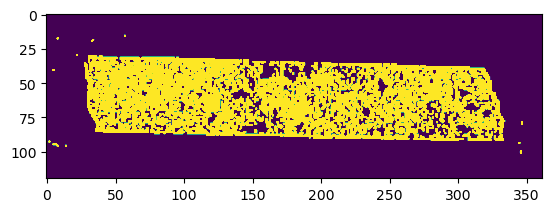

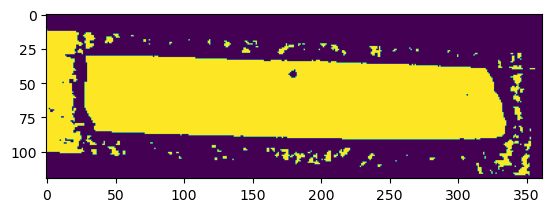

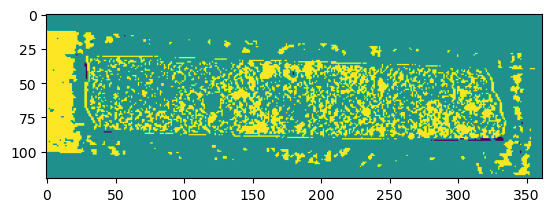

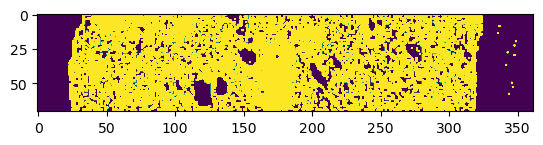

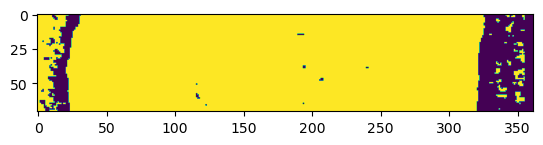

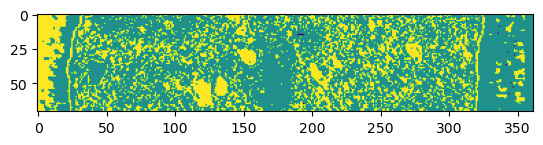

In [62]:
XA_temp = sitk.GetArrayFromImage(moving_temp)
NA_temp = sitk.GetArrayFromImage(moving_NA_temp)
plotter(XA_temp = XA_temp, DA_2 = DA_2)
plotter(XA_temp = NA_temp, DA_2 = DA_2)
plotter(XA_temp = XA_temp, DA_2 = NA_temp)

Save the data obtained usin the first method

In [63]:
#np.save('/dtu-compute/msaca/sliceA_diffraction/abs_volume/XA_registered_to_overview_abs_volume.npy', XA_temp)
#np.save('/dtu-compute/msaca/sliceA_diffraction/abs_volume/NA_registered_to_overview_abs_volume.npy', NA_temp)


In [ ]:
print(np.shape(XA_temp), type(XA_temp), XA_temp.dtype)

print(np.shape(DA_2), type(DA_2), DA_2.dtype)